In [24]:
import pandas as pd
import numpy as np

np.random.seed(42)

days = 730

dates = pd.date_range(
    start="2024-01-01",
    periods=days,
    freq="D"
)

day_of_year = dates.dayofyear

# حرارة موسمية
temperature = (
    25
    + 8 * np.sin(2 * np.pi * day_of_year / 365)
    + np.random.normal(0, 2, days)
)

# رطوبة موسمية
humidity = (
    65
    - 10 * np.sin(2 * np.pi * day_of_year / 365)
    + np.random.normal(0, 3, days)
)

# أمطار
rainfall = np.maximum(
    0,
    3 + 4 * np.cos(2 * np.pi * day_of_year / 365)
    + np.random.normal(0, 1, days)
)

# ري
irrigation = (
    140
    + 20 * np.sin(2 * np.pi * day_of_year / 365)
    + np.random.normal(0, 5, days)
)

# سماد
fertilizer = np.random.normal(20, 2, days)

# إنتاجية تعتمد على العوامل السابقة
yield_production = (
    40
    + 0.8 * temperature
    + 0.08 * irrigation
    + 0.6 * fertilizer
    + 0.3 * rainfall
    - 0.1 * humidity
    + np.random.normal(0, 2, days)
)

# نسبة الهدر
waste_rate = (
    8
    - 0.05 * rainfall
    + 0.03 * temperature
    + np.random.normal(0, 0.5, days)
)

df = pd.DataFrame({
    "Date": dates,
    "Temperature": temperature.round(1),
    "Humidity": humidity.round(1),
    "Rainfall": rainfall.round(1),
    "Irrigation": irrigation.round(1),
    "Fertilizer": fertilizer.round(1),
    "Yield": yield_production.round(2),
    "Waste_Rate": waste_rate.round(2)
})

df.to_csv("new_farm_dataset.csv", index=False)

df.head()

,Date,Temperature,Humidity,Rainfall,Irrigation,Fertilizer,Yield,Waste_Rate
0,2024-01-01,26.1,65.4,6.9,132.4,18.6,78.96,8.52
1,2024-01-02,25.0,61.7,5.8,143.0,21.5,80.99,8.55
2,2024-01-03,26.7,65.7,6.8,151.2,19.6,81.58,8.13
3,2024-01-04,28.6,59.2,6.1,134.6,19.9,79.84,8.65
4,2024-01-05,25.2,67.2,6.4,142.7,20.2,79.20,8.13


In [25]:
df.shape

(730, 8)

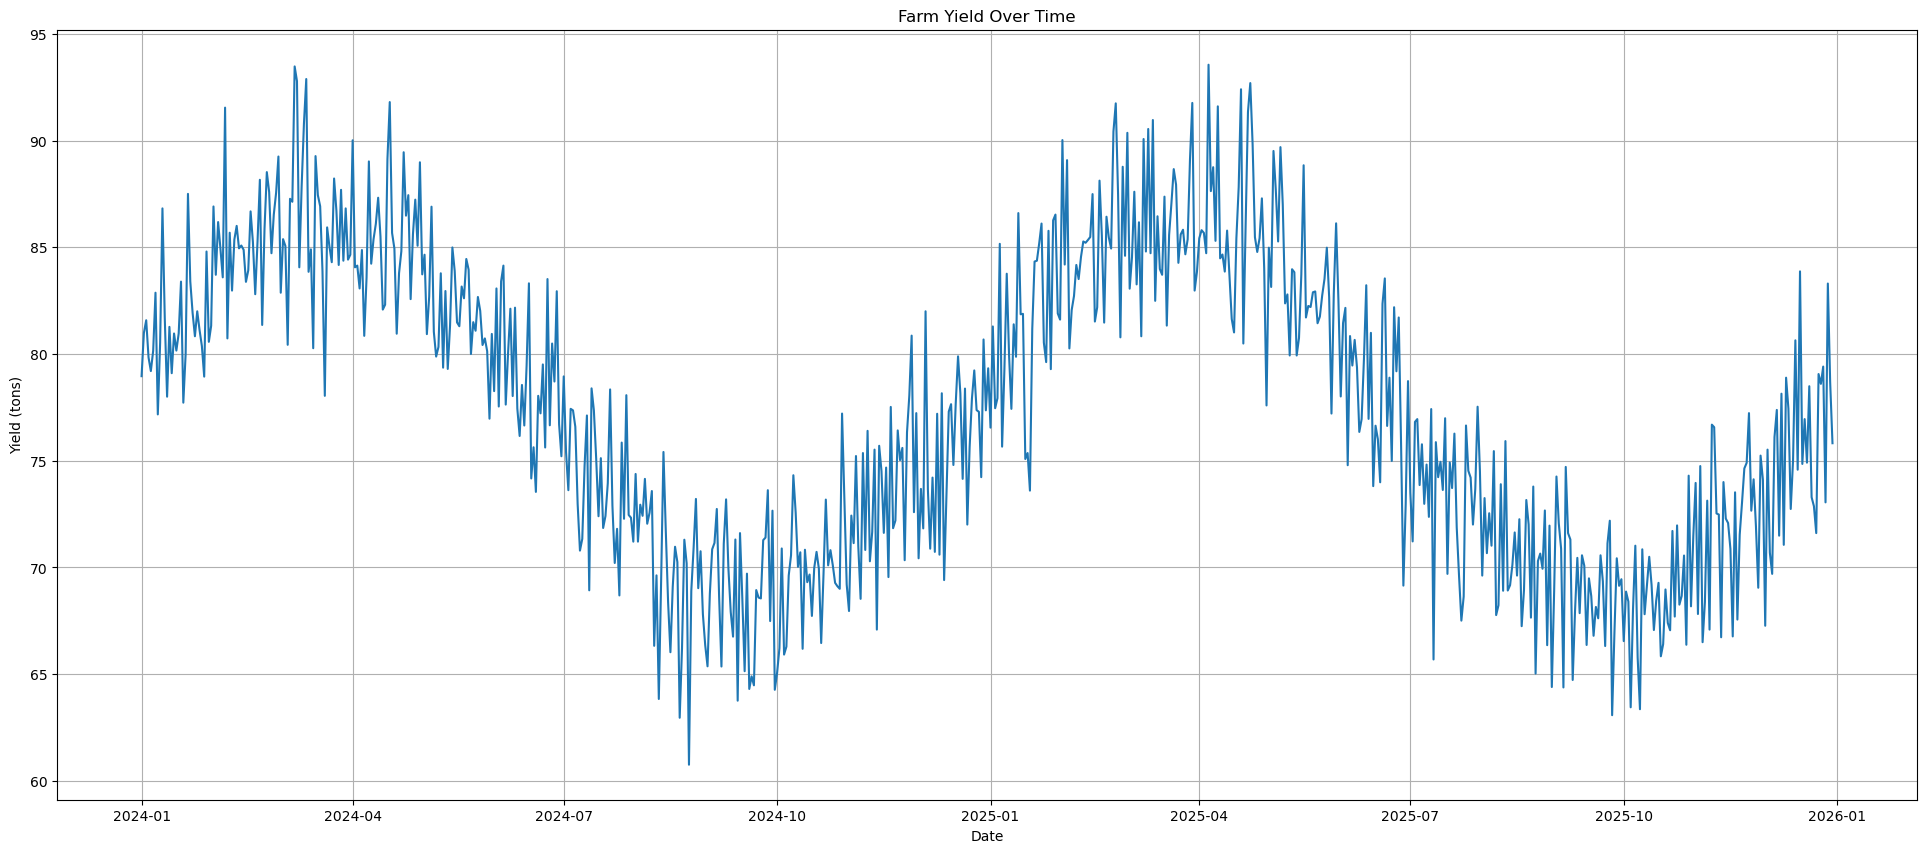

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24,10))

plt.plot(df["Date"], df["Yield"])

plt.title("Farm Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Yield (tons)")

plt.grid()

plt.show()

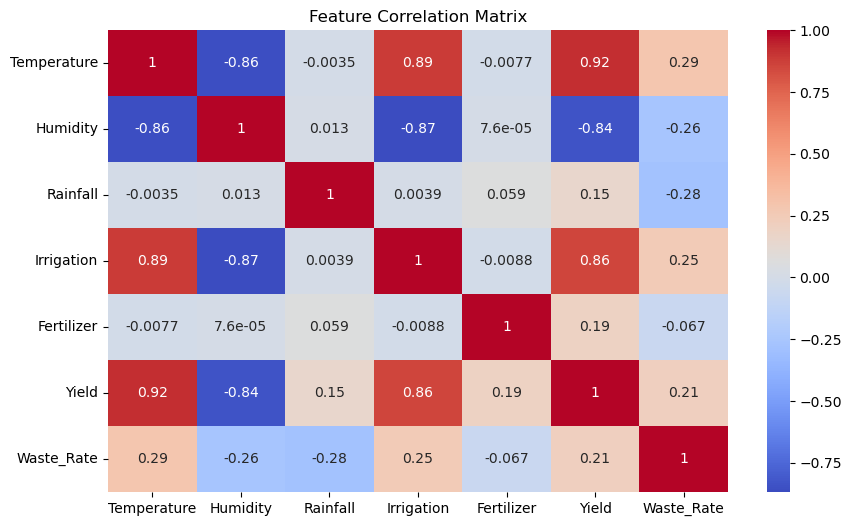

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop("Date", axis=1).corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [28]:
X = df[
    [
        "Temperature",
        "Humidity",
        "Rainfall",
        "Irrigation",
        "Fertilizer"
    ]
]

y = df["Yield"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("R2:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))

R2: 0.9202643751901146
MAE: 1.5340614383540232


In [31]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("R2:", r2_score(y_test, pred_dt))
print("MAE:", mean_absolute_error(y_test, pred_dt))

R2: 0.8593623794718175
MAE: 2.0983044707420944


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("R2:", r2_score(y_test, pred_gb))
print("MAE:", mean_absolute_error(y_test, pred_gb))

R2: 0.8904423530182599
MAE: 1.8207117641790014


In [33]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("R2:", r2_score(y_test, pred_xgb))
print("MAE:", mean_absolute_error(y_test, pred_xgb))

R2: 0.8839951701447644
MAE: 1.8306820218857018


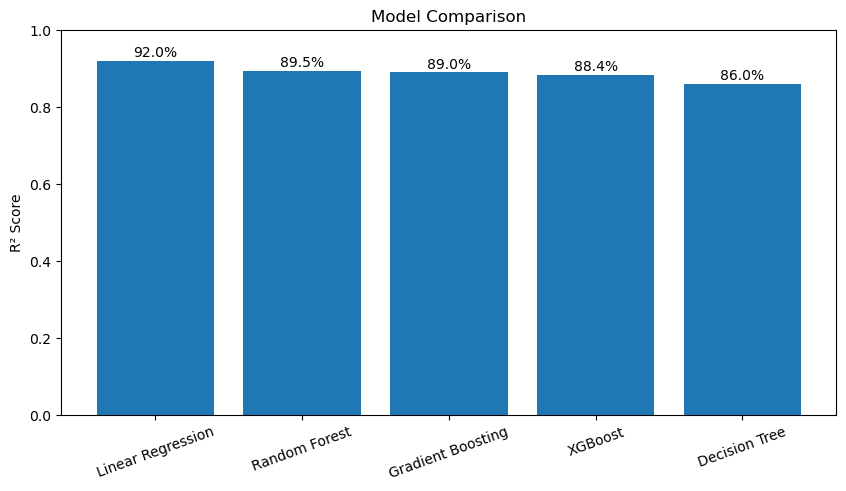

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2": [
        0.920,
        0.860,
        0.895,
        0.890,
        0.884
    ]
})

results = results.sort_values("R2", ascending=False)

plt.figure(figsize=(10,5))

bars = plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

# كتابة القيمة فوق كل عمود
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.1f}%",
        ha='center'
    )

plt.show()

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

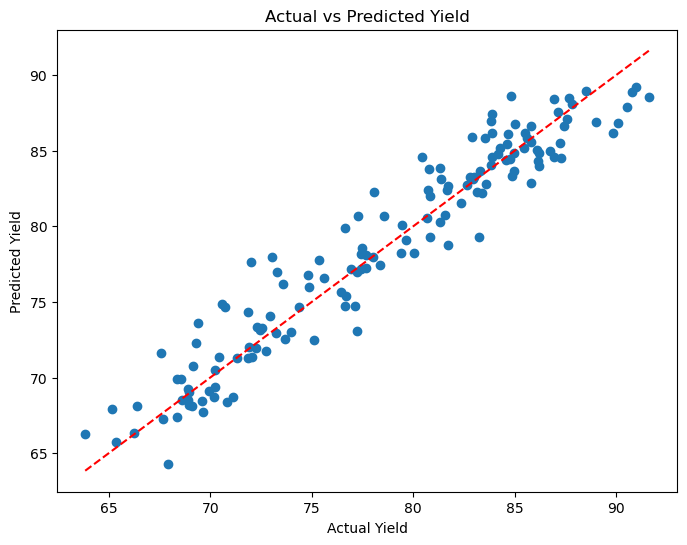

In [37]:
pred_lr = lr.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [38]:
next_week = pd.DataFrame({
    "Temperature":[30,31,29,30,32,31,30],
    "Humidity":[55,54,58,57,56,55,54],
    "Rainfall":[3,4,2,1,3,4,2],
    "Irrigation":[160,160,165,160,170,165,160],
    "Fertilizer":[22,22,22,22,22,22,22]
})

weekly_prediction = lr.predict(next_week)

print(weekly_prediction)

[85.27932931 86.60884874 84.04382771 84.28525623 87.45984737 86.81203878
 85.00063718]


In [39]:
total_production = weekly_prediction.sum()

print(f"Expected Production = {total_production:.2f} tons")

Expected Production = 599.49 tons


In [40]:
price_per_ton = 12000

revenue = total_production * price_per_ton
print(revenue)

7193877.42398343


In [41]:
import math

truck_capacity = 15

trucks_needed = math.ceil(
    total_production / truck_capacity
)

print(f"Required Trucks = {trucks_needed}")

Required Trucks = 40


In [42]:
print("="*40)
print("WEEKLY FARM FORECAST REPORT")
print("="*40)

print(f"Expected Production : {total_production:.2f} tons")
print(f"Required Trucks     : {trucks_needed}")
print(f"Expected Revenue    : {revenue:,.0f} EGP")
print(f"Model R² Score      : 92.0%")

print("="*40)

WEEKLY FARM FORECAST REPORT
Expected Production : 599.49 tons
Required Trucks     : 40
Expected Revenue    : 7,193,877 EGP
Model R² Score      : 92.0%


In [43]:
import joblib

joblib.dump(lr, "yield_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [44]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

pdf_path = (
    rf"C:\Users\Admin\.n8n-files\Weekly_Farm_Report_{timestamp}.pdf"
)

report = pd.DataFrame({
    "Expected_Production":[round(total_production,2)],
    "Required_Trucks":[trucks_needed],
    "Expected_Revenue":[round(revenue,0)],
    "Model_R2":[0.92]
})

report.to_csv("weekly_forecast_report.csv", index=False)

report

,Expected_Production,Required_Trucks,Expected_Revenue,Model_R2
0,599.49,40,7193877.0,0.92


In [45]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate(pdf_path)


styles = getSampleStyleSheet()

content = []

title = Paragraph(
    "Weekly Farm Forecast Report",
    styles["Title"]
)

content.append(title)

content.append(Spacer(1,12))

content.append(
    Paragraph(
        f"Expected Production: {total_production:.2f} tons",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Required Trucks: {trucks_needed}",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        f"Expected Revenue: {revenue:,.0f} EGP",
        styles["Normal"]
    )
)

content.append(
    Paragraph(
        "Model Accuracy (R²): 92%",
        styles["Normal"]
    )
)

doc.build(content)

print("PDF Created Successfully!")

print(pdf_path)

with open(
    r"C:\Users\Admin\.n8n-files\latest_report.txt",
    "w"
) as f:
    f.write(pdf_path)

PDF Created Successfully!
C:\Users\Admin\.n8n-files\Weekly_Farm_Report_20260607_094154.pdf
